# Distribuições discretas

**Tema:** Estatística › Distribuições de Probabilidade

Neste notebook cada distribuição é apresentada pela **história que a gera**, não
pela fórmula. A fórmula vem depois, como consequência.

A meta prática é você conseguir olhar para uma coluna de dados de contagem e
dizer, com argumento, qual modelo cabe ali.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2024)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86"
print("pronto")

pronto


## 1. Bernoulli: o átomo de tudo

**História:** um experimento, dois resultados. Converteu (1) ou não (0).

Parece trivial demais para merecer um nome. Mas repare numa consequência que
tem impacto direto em planejamento de testes A/B: a variância $p(1-p)$ **não é
constante** — ela depende da própria taxa que você está medindo.

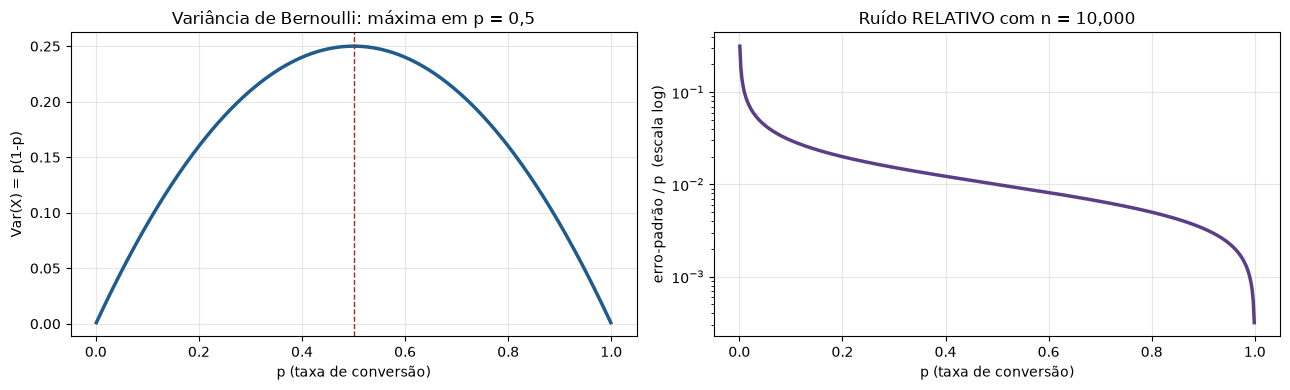

p =  0.500 -> erro-padrão = 0.00500  (  1.0% do próprio p)
p =  0.100 -> erro-padrão = 0.00300  (  3.0% do próprio p)
p =  0.010 -> erro-padrão = 0.00099  (  9.9% do próprio p)
p =  0.001 -> erro-padrão = 0.00032  ( 31.6% do próprio p)


In [2]:
p_grade = np.linspace(0.001, 0.999, 500)
variancia = p_grade * (1 - p_grade)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(p_grade, variancia, lw=2.5, color=AZUL)
ax1.axvline(0.5, ls="--", color=VERMELHO, lw=1)
ax1.set_title("Variância de Bernoulli: máxima em p = 0,5")
ax1.set_xlabel("p (taxa de conversão)")
ax1.set_ylabel("Var(X) = p(1-p)")

# O que realmente importa num teste A/B não é a variância absoluta, e sim o
# ruído RELATIVO ao efeito que você quer detectar.
# Coeficiente de variação de uma proporção estimada com n observações:
#   CV = sqrt(p(1-p)/n) / p
n_amostra = 10_000
cv = np.sqrt(variancia / n_amostra) / p_grade
ax2.plot(p_grade, cv, lw=2.5, color=ROXO)
ax2.set_yscale("log")
ax2.set_title(f"Ruído RELATIVO com n = {n_amostra:,}")
ax2.set_xlabel("p (taxa de conversão)")
ax2.set_ylabel("erro-padrão / p  (escala log)")

plt.tight_layout()
plt.show()

for p in [0.5, 0.10, 0.01, 0.001]:
    ep = np.sqrt(p * (1 - p) / n_amostra)
    print(f"p = {p:6.3f} -> erro-padrão = {ep:.5f}  "
          f"({ep / p:6.1%} do próprio p)")

O painel da direita é o insight que raramente se ensina: com o mesmo $n$, medir
uma conversão de 0,1% tem ruído relativo **31 vezes maior** do que medir uma de
50%. É por isso que otimizar métricas raras (compra de plano anual, fraude,
churn) exige amostras ordens de magnitude maiores.

## 2. Binomial: somando Bernoullis

**História:** $n$ tentativas independentes, mesmo $p$, conte os sucessos.

Vamos verificar computacionalmente que a binomial é literalmente a soma.

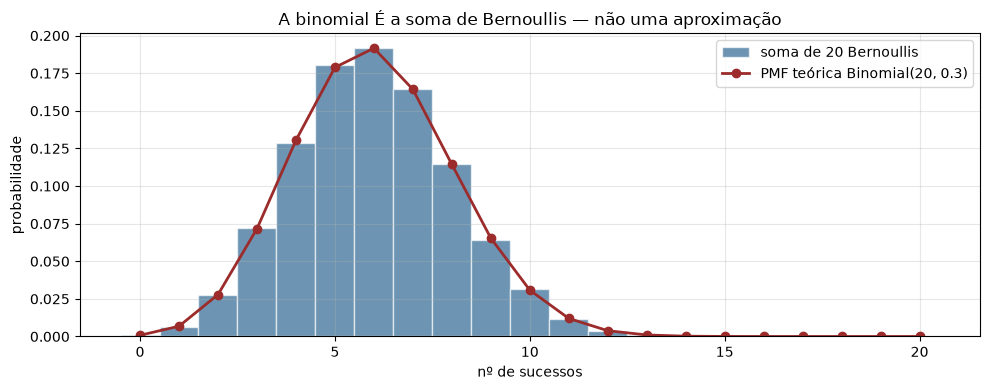

Média simulada  = 6.0001   |  teórica np = 6.0000
Variância simul.= 4.1859   |  teórica np(1-p) = 4.2000


In [3]:
n, p = 20, 0.3
n_sim = 200_000

# Caminho 1: somar n Bernoullis simulados
bernoullis = rng.random(size=(n_sim, n)) < p
soma_simulada = bernoullis.sum(axis=1)

# Caminho 2: a fórmula fechada da binomial
k = np.arange(0, n + 1)
pmf_teorica = stats.binom.pmf(k, n, p)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(soma_simulada, bins=np.arange(-0.5, n + 1.5), density=True,
        color=AZUL, alpha=0.65, edgecolor="white", label="soma de 20 Bernoullis")
ax.plot(k, pmf_teorica, "o-", color=VERMELHO, lw=2, ms=6,
        label="PMF teórica Binomial(20, 0.3)")
ax.set_xlabel("nº de sucessos")
ax.set_ylabel("probabilidade")
ax.set_title("A binomial É a soma de Bernoullis — não uma aproximação")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Média simulada  = {soma_simulada.mean():.4f}   |  teórica np = {n*p:.4f}")
print(f"Variância simul.= {soma_simulada.var(ddof=1):.4f}   |  teórica np(1-p) = {n*p*(1-p):.4f}")

## 3. Poisson: eventos raros num intervalo

**História:** eventos acontecem de forma independente a uma taxa média
constante $\lambda$. Conte quantos ocorreram no intervalo.

Vamos ver a Poisson **emergir** da binomial: muitas oportunidades, cada uma
improvável.

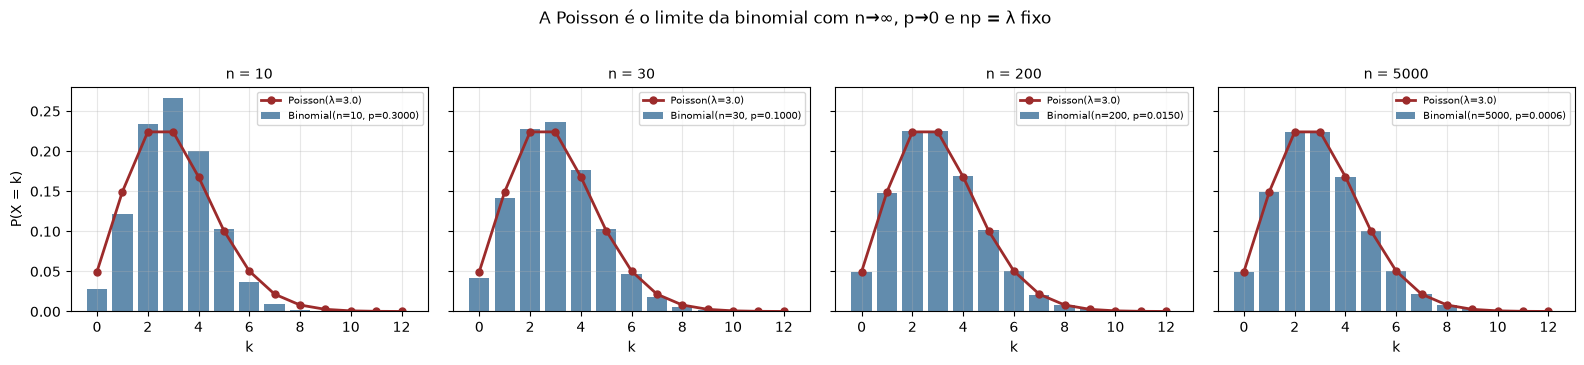

In [4]:
LAMBDA = 3.0
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, n_tentativas in zip(axes, [10, 30, 200, 5000]):
    p_i = LAMBDA / n_tentativas          # mantém n·p = lambda constante
    k = np.arange(0, 13)
    ax.bar(k, stats.binom.pmf(k, n_tentativas, p_i), color=AZUL, alpha=0.7,
           label=f"Binomial(n={n_tentativas}, p={p_i:.4f})")
    ax.plot(k, stats.poisson.pmf(k, LAMBDA), "o-", color=VERMELHO, lw=2, ms=5,
            label=f"Poisson(λ={LAMBDA})")
    ax.set_title(f"n = {n_tentativas}", fontsize=10)
    ax.set_xlabel("k")
    ax.legend(fontsize=7)
axes[0].set_ylabel("P(X = k)")
plt.suptitle("A Poisson é o limite da binomial com n→∞, p→0 e np = λ fixo", y=1.03)
plt.tight_layout()
plt.show()

> **Analogia:** imagine a fila de um pronto-socorro. Existem milhões de pessoas
> na cidade (n enorme) e a chance de qualquer pessoa específica precisar do PS
> hoje é minúscula (p minúsculo). O que você observa é a Poisson: um número
> médio estável de chegadas por hora, com flutuação.

## 4. O diagnóstico de campo mais útil: Var / média

A Poisson tem a assinatura **média = variância**. Essa é a checagem que separa
quem sabe usar contagem de quem só chuta.

In [5]:
n_obs = 20_000

# Cenário A: processo Poisson genuíno — taxa constante para todo mundo
poisson_puro = rng.poisson(lam=4.0, size=n_obs)

# Cenário B: heterogeneidade. Cada cliente tem SUA taxa, sorteada de uma gama.
# Isso é o que acontece em qualquer base real: clientes não são idênticos.
taxas_individuais = rng.gamma(shape=1.2, scale=4.0 / 1.2, size=n_obs)
superdisperso = rng.poisson(lam=taxas_individuais)

# Cenário C: excesso de zeros. Boa parte da base NUNCA faz o evento
# (nunca abre o app, nunca reclama), e o resto segue uma Poisson.
nunca_engaja = rng.random(n_obs) < 0.45
inflado_zero = np.where(nunca_engaja, 0, rng.poisson(lam=6.0, size=n_obs))

cenarios = {
    "Poisson puro": poisson_puro,
    "Superdisperso (clientes heterogêneos)": superdisperso,
    "Inflado em zero (45% nunca engajam)": inflado_zero,
}

print(f"{'cenário':40s} {'média':>8s} {'variância':>11s} {'Var/média':>11s} {'% zeros':>9s}")
print("-" * 84)
for nome, v in cenarios.items():
    razao = v.var(ddof=1) / v.mean()
    print(f"{nome:40s} {v.mean():>8.3f} {v.var(ddof=1):>11.3f} "
          f"{razao:>11.3f} {(v == 0).mean():>8.1%}")

cenário                                     média   variância   Var/média   % zeros
------------------------------------------------------------------------------------
Poisson puro                                3.999       3.999       1.000     1.8%
Superdisperso (clientes heterogêneos)       4.004      17.176       4.290    17.1%
Inflado em zero (45% nunca engajam)         3.326      12.287       3.694    45.0%


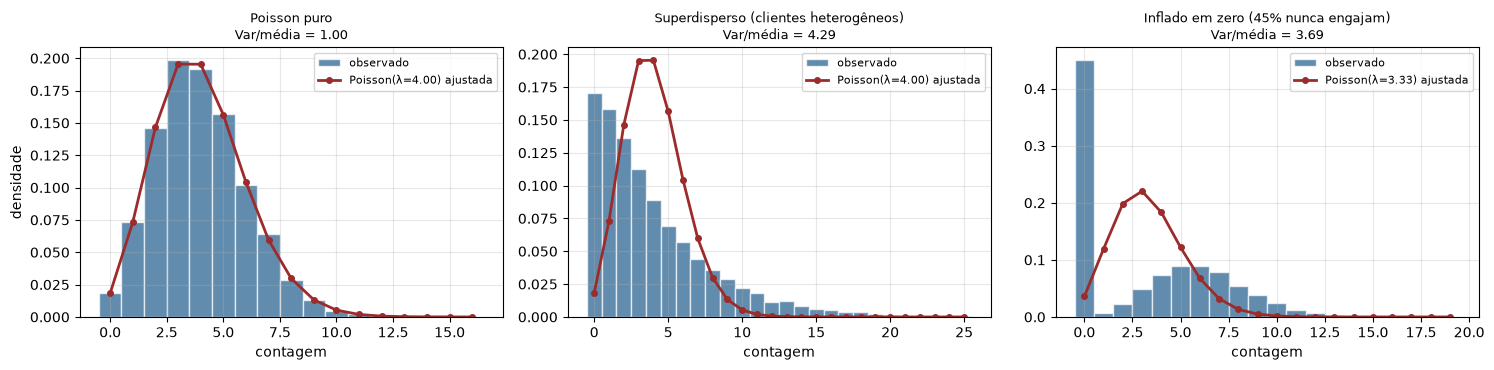

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (nome, v) in zip(axes, cenarios.items()):
    maximo = min(v.max(), 25)
    k = np.arange(0, maximo + 1)
    ax.hist(v, bins=np.arange(-0.5, maximo + 1.5), density=True,
            color=AZUL, alpha=0.7, edgecolor="white", label="observado")
    # A Poisson ajustada por método dos momentos (lambda = média amostral)
    ax.plot(k, stats.poisson.pmf(k, v.mean()), "o-", color=VERMELHO,
            lw=2, ms=4, label=f"Poisson(λ={v.mean():.2f}) ajustada")
    ax.set_title(f"{nome}\nVar/média = {v.var(ddof=1)/v.mean():.2f}", fontsize=9.5)
    ax.set_xlabel("contagem")
    ax.legend(fontsize=8)
axes[0].set_ylabel("densidade")
plt.tight_layout()
plt.show()

Leia os três painéis:

* **Esquerda:** razão ≈ 1, e a Poisson ajustada cobre o histograma. Modelo certo.
* **Centro:** razão ≈ 4. A Poisson ajustada **subestima os zeros e as caudas** ao
  mesmo tempo. Diagnóstico: superdispersão → use **binomial negativa**.
* **Direita:** razão > 1 e uma barra gigante em zero que a Poisson não explica.
  Diagnóstico: **inflação de zeros** → use modelo zero-inflado ou *hurdle*.

> **Por que isso é caro no mercado:** se você ajusta uma Poisson a dados
> superdispersos, os erros-padrão dos coeficientes saem **pequenos demais**.
> Você reporta que a variável X tem efeito significativo (p = 0,01) quando na
> verdade o p correto seria 0,3. Decisões de produto são tomadas em cima de um
> efeito que não existe.

## 5. Binomial negativa: a Poisson com heterogeneidade

Vamos ajustar a binomial negativa ao cenário B e mostrar que ela acerta onde a
Poisson erra.

média = 4.004 | variância = 17.176
r estimado = 1.217 | p estimado = 0.233


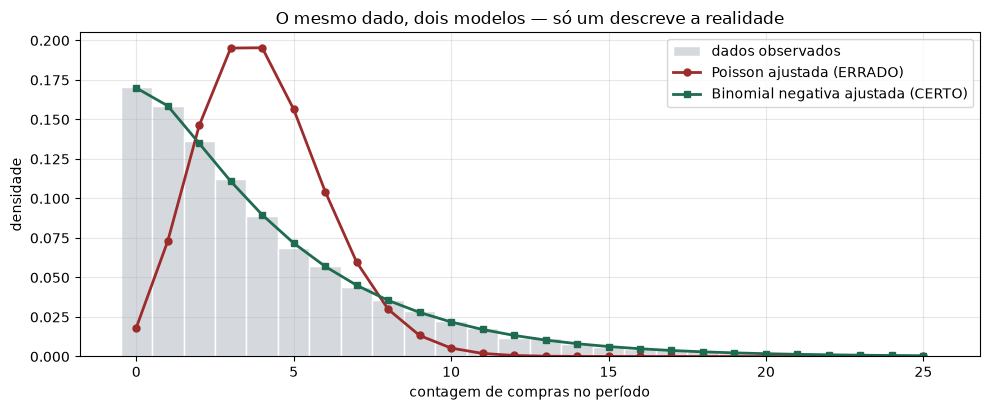


Erro absoluto total  Poisson         : 0.6987
Erro absoluto total  Binomial negativa: 0.0170
A binomial negativa é 41.0x melhor neste ajuste.


In [7]:
v = superdisperso
mu = v.mean()
sigma2 = v.var(ddof=1)

# Método dos momentos para a binomial negativa:
#   Var = mu + mu²/r   =>   r = mu² / (Var - mu)
r_estimado = mu ** 2 / (sigma2 - mu)
# scipy parametriza como nbinom(n=r, p=r/(r+mu))
p_estimado = r_estimado / (r_estimado + mu)

print(f"média = {mu:.3f} | variância = {sigma2:.3f}")
print(f"r estimado = {r_estimado:.3f} | p estimado = {p_estimado:.3f}")

k = np.arange(0, 26)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(v, bins=np.arange(-0.5, 26.5), density=True, color="#D5D9DE",
        edgecolor="white", label="dados observados")
ax.plot(k, stats.poisson.pmf(k, mu), "o-", color=VERMELHO, lw=2, ms=5,
        label="Poisson ajustada (ERRADO)")
ax.plot(k, stats.nbinom.pmf(k, r_estimado, p_estimado), "s-", color=VERDE,
        lw=2, ms=5, label="Binomial negativa ajustada (CERTO)")
ax.set_xlabel("contagem de compras no período")
ax.set_ylabel("densidade")
ax.set_title("O mesmo dado, dois modelos — só um descreve a realidade")
ax.legend()
plt.tight_layout()
plt.show()

# Qualidade do ajuste: distância entre a PMF do modelo e a frequência observada
observado = np.array([(v == i).mean() for i in k])
erro_poisson = np.abs(observado - stats.poisson.pmf(k, mu)).sum()
erro_nbinom = np.abs(observado - stats.nbinom.pmf(k, r_estimado, p_estimado)).sum()
print(f"\nErro absoluto total  Poisson         : {erro_poisson:.4f}")
print(f"Erro absoluto total  Binomial negativa: {erro_nbinom:.4f}")
print(f"A binomial negativa é {erro_poisson/erro_nbinom:.1f}x melhor neste ajuste.")

## 6. Geométrica e a falta de memória

**História:** tentativas repetidas até o primeiro sucesso.

A propriedade de falta de memória é contraintuitiva e vale ser testada: "já
tentei 10 vezes, agora *tem* que dar certo" é a falácia do apostador. A
matemática discorda.

In [8]:
p_sucesso = 0.15
amostras = rng.geometric(p=p_sucesso, size=500_000)

print("P(precisar de mais k tentativas), dado que já falhou s vezes:")
print(f"{'s (já falhou)':>15s} {'P(X > s+3 | X > s)':>20s}")
print("-" * 38)
for s in [0, 5, 10, 20, 40]:
    sobreviventes = amostras[amostras > s]
    prob = (sobreviventes > s + 3).mean()
    print(f"{s:>15d} {prob:>20.4f}")
print(f"\nValor teórico (1-p)³ = {(1 - p_sucesso) ** 3:.4f} — igual em todas as linhas.")
print("O processo não 'lembra' de quantas vezes você já falhou.")

P(precisar de mais k tentativas), dado que já falhou s vezes:
  s (já falhou)   P(X > s+3 | X > s)
--------------------------------------
              0               0.6141
              5               0.6141
             10               0.6141
             20               0.6069
             40               0.6243

Valor teórico (1-p)³ = 0.6141 — igual em todas as linhas.
O processo não 'lembra' de quantas vezes você já falhou.


## 7. Tabela-resumo para consulta

In [9]:
resumo = pd.DataFrame([
    ("Bernoulli", "p", "p", "p(1-p)", "Um evento binário", "Conversão de uma visita"),
    ("Binomial", "n, p", "np", "np(1-p)", "Sucessos em n tentativas iguais",
     "Cliques em 1000 impressões"),
    ("Poisson", "λ", "λ", "λ", "Eventos raros, taxa constante",
     "Chamados por hora no call center"),
    ("Binomial negativa", "r, p", "μ", "μ + μ²/r", "Contagem com heterogeneidade",
     "Compras por cliente no mês"),
    ("Geométrica", "p", "1/p", "(1-p)/p²", "Tentativas até o 1º sucesso",
     "Contatos até fechar uma venda"),
    ("Hipergeométrica", "N, K, n", "nK/N", "—", "Amostragem SEM reposição",
     "Auditoria de lote de peças"),
], columns=["Distribuição", "Parâmetros", "Média", "Variância",
            "História que a gera", "Exemplo de mercado"])
resumo

,Distribuição,Parâmetros,Média,Variância,História que a gera,Exemplo de mercado
0,Bernoulli,p,p,p(1-p),Um evento binário,Conversão de uma visita
1,Binomial,"n, p",np,np(1-p),Sucessos em n tentativas iguais,Cliques em 1000 impressões
2,Poisson,λ,λ,λ,"Eventos raros, taxa constante",Chamados por hora no call center
3,Binomial negativa,"r, p",μ,μ + μ²/r,Contagem com heterogeneidade,Compras por cliente no mês
4,Geométrica,p,1/p,(1-p)/p²,Tentativas até o 1º sucesso,Contatos até fechar uma venda
5,Hipergeométrica,"N, K, n",nK/N,—,Amostragem SEM reposição,Auditoria de lote de peças


> **Sobre a hipergeométrica:** ela é a binomial *sem reposição*. Quando a
> população é grande em relação à amostra (regra prática: $n < 5\%$ de $N$), as
> duas coincidem e ninguém se preocupa. Quando você audita 50 peças de um lote
> de 200, a diferença importa.

## 8. Exercícios

1. Um servidor recebe em média 240 requisições por minuto. Qual a probabilidade
   de receber mais de 300 em algum minuto? Use `stats.poisson.sf`. Depois
   calcule quantas requisições você precisa suportar para cobrir 99,9% dos
   minutos — esse número é o dimensionamento de capacidade real.
2. Simule um teste A/B com $p_A = 0{,}020$ e $p_B = 0{,}022$ (10% de melhora
   relativa). Com $n = 10.000$ por grupo, com que frequência você detecta a
   diferença? E com $n = 100.000$? Relacione com a seção 1.
3. Pegue o cenário C (inflado em zero) e ajuste um modelo *hurdle*: uma
   Bernoulli para "engaja ou não" e uma Poisson truncada em zero para quem
   engaja. Compare o erro de ajuste com o da Poisson simples.
4. Prove numericamente que a soma de duas Poissons independentes,
   $\text{Poisson}(\lambda_1) + \text{Poisson}(\lambda_2)$, é
   $\text{Poisson}(\lambda_1 + \lambda_2)$. Isso vale para a binomial negativa?

## Próximo passo

`02-continuas.ipynb` — normal, log-normal, exponencial, Weibull e a arte de
reconhecer qual delas gerou seus dados.